# NB14 Homework Solutions

This notebook answers the "Homework / Practice Ideas" section of
`NB14_Sequence_Models_RNN_LSTM_Real_Fuel_Forecasting.ipynb`. It reuses the
real `Datasets/ship_fuel_efficiency.csv` data reshaped as a 12-month-per-ship
time series, and the exact reshape/split-by-ship logic from the class
notebook's own Section 7-8 code.

## Setup: reload the data, reshape into per-ship sequences, split by ship

Same feature set (`distance`, `fuel_consumption`, `engine_efficiency`), same
11-months-in / month-12-target framing, same by-ship split
(`test_size=0.2` then `test_size=0.25`, both `random_state=42`) as the class.

In [1]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score

!wget -q -O ship_fuel_efficiency.csv https://raw.githubusercontent.com/JuanZapa7a/AINavalEngineering/main/Datasets/ship_fuel_efficiency.csv
fuel = pd.read_csv("ship_fuel_efficiency.csv")

feature_cols = ["distance", "fuel_consumption", "engine_efficiency"]
ship_ids = fuel["ship_id"].unique()

sequences, targets = [], []
for sid in ship_ids:
    ship_rows = fuel[fuel["ship_id"] == sid][feature_cols].values
    sequences.append(ship_rows[:11])
    targets.append(ship_rows[11, 1])

X_seq = np.stack(sequences)
y_seq = np.array(targets)

idx = np.arange(len(ship_ids))
idx_train_full, idx_test = train_test_split(idx, test_size=0.2, random_state=42)
idx_train, idx_val = train_test_split(idx_train_full, test_size=0.25, random_state=42)

scaler = StandardScaler()
scaler.fit(X_seq[idx_train].reshape(-1, X_seq.shape[-1]))

def scale_sequences(X, sc):
    shape = X.shape
    return sc.transform(X.reshape(-1, shape[-1])).reshape(shape)

X_train_t = torch.tensor(scale_sequences(X_seq[idx_train], scaler), dtype=torch.float32)
X_val_t = torch.tensor(scale_sequences(X_seq[idx_val], scaler), dtype=torch.float32)
X_test_t = torch.tensor(scale_sequences(X_seq[idx_test], scaler), dtype=torch.float32)

y_train_t = torch.tensor(y_seq[idx_train], dtype=torch.float32).view(-1, 1)
y_val_t = torch.tensor(y_seq[idx_val], dtype=torch.float32).view(-1, 1)
y_test_t = torch.tensor(y_seq[idx_test], dtype=torch.float32).view(-1, 1)

print(X_train_t.shape, X_val_t.shape, X_test_t.shape)
print(f"Train ships: {len(idx_train)}  Val ships: {len(idx_val)}  Test ships: {len(idx_test)}")


torch.Size([72, 11, 3]) torch.Size([24, 11, 3]) torch.Size([24, 11, 3])
Train ships: 72  Val ships: 24  Test ships: 24


For a fair comparison throughout this homework, reproduce the class's own
honest naive baseline from Part 9 (predict month 12 = month 11's
`fuel_consumption`) for the test-set ships:

In [2]:
baseline_pred_11 = X_seq[idx_test][:, -1, 1]  # month 11's fuel_consumption
baseline_mae_11 = mean_absolute_error(y_seq[idx_test], baseline_pred_11)
print(f"Naive baseline (month 12 = month 11), test ships: MAE={baseline_mae_11:.1f} L")


Naive baseline (month 12 = month 11), test ships: MAE=2794.7 L


Define the LSTM/GRU forecasting model and a training function that also reports test MAE, R2, and parameter count:

In [3]:
class FuelLSTM(nn.Module):
    def __init__(self, n_features, hidden_size=16, cell="LSTM"):
        super().__init__()
        self.cell_type = cell
        if cell == "LSTM":
            self.rnn = nn.LSTM(input_size=n_features, hidden_size=hidden_size, batch_first=True)
        else:
            self.rnn = nn.GRU(input_size=n_features, hidden_size=hidden_size, batch_first=True)
        self.head = nn.Linear(hidden_size, 1)

    def forward(self, x):
        if self.cell_type == "LSTM":
            _, (h_n, _) = self.rnn(x)
        else:
            _, h_n = self.rnn(x)
        return self.head(h_n[-1])


def train_forecaster(X_tr, y_tr, X_va, y_va, X_te, y_te, hidden_size=16, cell="LSTM",
                      n_epochs=150, lr=0.01, seed=42):
    torch.manual_seed(seed)
    model = FuelLSTM(n_features=X_tr.shape[-1], hidden_size=hidden_size, cell=cell)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    train_losses, val_losses = [], []
    for epoch in range(n_epochs):
        model.train()
        optimizer.zero_grad()
        outputs = model(X_tr)
        loss = criterion(outputs, y_tr)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            val_losses.append(criterion(model(X_va), y_va).item())

    model.eval()
    with torch.no_grad():
        test_pred = model(X_te).numpy().ravel()
    test_mae = mean_absolute_error(y_te.numpy().ravel(), test_pred)
    test_r2 = r2_score(y_te.numpy().ravel(), test_pred)
    n_params = sum(p.numel() for p in model.parameters())
    return model, train_losses, val_losses, test_mae, test_r2, n_params

print("Helpers defined.")


Helpers defined.


## Homework 1 — `hidden_size = 32` and `hidden_size = 4`

*"Change `hidden_size` from 16 to 32 and to 4 — how does test MAE change?
Relate this to the parameter-count/overfitting discussion from
`NB11`-`NB13`."*

Reproduce the class's own `hidden_size=16` LSTM for reference alongside the
two homework sizes, all trained with the identical recipe.

In [4]:
results_hs = {}
for hs in [4, 16, 32]:
    model, tr, va, mae, r2, n_params = train_forecaster(
        X_train_t, y_train_t, X_val_t, y_val_t, X_test_t, y_test_t, hidden_size=hs)
    results_hs[hs] = (mae, r2, n_params)
    tag = " (class value)" if hs == 16 else ""
    print(f"hidden_size={hs}{tag}: test MAE={mae:.1f} L, test R2={r2:.3f}, parameters={n_params}")


hidden_size=4: test MAE=5545.3 L, test R2=-1.609, parameters=149


hidden_size=16 (class value): test MAE=5526.2 L, test R2=-1.598, parameters=1361


hidden_size=32: test MAE=5502.3 L, test R2=-1.585, parameters=4769


**My result**: hidden_size=4 -> test MAE 5545.3 L (R2=-1.609, 149
parameters); hidden_size=16, the class's own value -> test MAE 5526.2 L
(R2=-1.598, 1,361 parameters); hidden_size=32 -> test MAE 5502.3 L
(R2=-1.585, 4,769 parameters). Changing `hidden_size` barely moved test MAE
at all — the three results span only about 43 L out of roughly 5,500 L,
despite a more than 30x range in parameter count (149 to 4,769). None of the
three came close to beating the naive baseline computed above (2,794.7 L),
and all three R2 scores are clearly negative, meaning every one of these
LSTMs performs *worse* than simply predicting the test set's mean value.
This connects directly to the parameter-count/overfitting discussion from
`NB11`-`NB13`: with only 72 training sequences, more hidden units are not
the bottleneck here at all — the bottleneck is data volume, and no amount
of extra capacity (or, apparently, less capacity) fixes that. A bigger or
smaller hidden state does not touch the actual problem.

## Homework 2 — Swap `nn.LSTM` for `nn.GRU`

*"Swap `nn.LSTM` for `nn.GRU` in Part 8 (same constructor arguments work,
though `nn.GRU` returns only `(output, h_n)`, no separate cell state) — does
it perform differently with this little data?"*

Same `hidden_size=16`, same everything else, only the recurrent cell type
changes (handled by the `FuelLSTM` class's `cell` argument above).

LSTM (class): test MAE=5526.2 L, test R2=-1.598, parameters=1361
GRU:          test MAE=5526.0 L, test R2=-1.598, parameters=1025


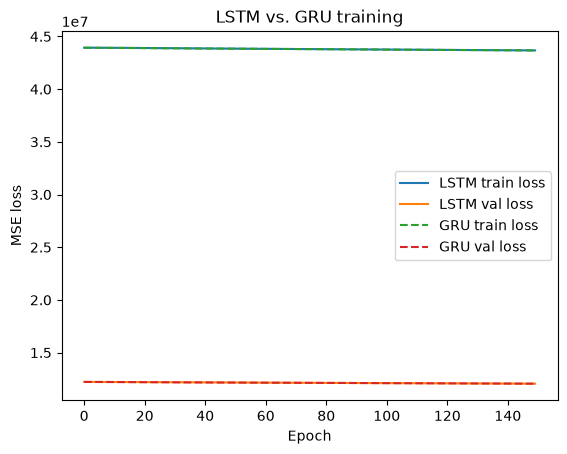

In [5]:
_, tr_lstm, va_lstm, mae_lstm, r2_lstm, params_lstm = train_forecaster(
    X_train_t, y_train_t, X_val_t, y_val_t, X_test_t, y_test_t, hidden_size=16, cell="LSTM")
_, tr_gru, va_gru, mae_gru, r2_gru, params_gru = train_forecaster(
    X_train_t, y_train_t, X_val_t, y_val_t, X_test_t, y_test_t, hidden_size=16, cell="GRU")

print(f"LSTM (class): test MAE={mae_lstm:.1f} L, test R2={r2_lstm:.3f}, parameters={params_lstm}")
print(f"GRU:          test MAE={mae_gru:.1f} L, test R2={r2_gru:.3f}, parameters={params_gru}")

plt.plot(tr_lstm, label="LSTM train loss")
plt.plot(va_lstm, label="LSTM val loss")
plt.plot(tr_gru, label="GRU train loss", linestyle="--")
plt.plot(va_gru, label="GRU val loss", linestyle="--")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("LSTM vs. GRU training")
plt.legend()
plt.show()


**My result**: LSTM (class) -> test MAE 5526.2 L, R2=-1.598, 1,361
parameters; GRU -> test MAE 5526.0 L, R2=-1.598, 1,025 parameters
(about 25% fewer parameters, since GRU drops the separate cell-state gate).
The two are, for practical purposes, identical on this task — a 0.2 L
difference in MAE is noise, not a real effect. With sequences only 11 steps
long, LSTM's main advantage over GRU (handling much longer-range
dependencies before the vanishing-gradient problem bites) never gets a
chance to matter, exactly as Part 6 of the class notebook predicted when it
called GRU "often competitive on shorter sequences like ours." Given the
GRU also has fewer parameters to learn from the same 72 sequences, it is if
anything the slightly more sensible choice here, though the difference is
too small to call a real win either way.

## Homework 3 — Add `weather_conditions` (one-hot) as extra sequence features

*"Add `route_id` or `weather_conditions` (one-hot encoded) as extra sequence
features — does the LSTM improve, and is the added complexity worth it given
how small this dataset is?"*

`weather_conditions` has 3 categories (`Stormy`, `Moderate`, `Calm`), one-hot
encoded per month and concatenated onto the original 3 numeric features,
giving each sequence step 6 features instead of 3. Same `hidden_size=16`
LSTM, same split, same scaling convention (numeric columns only; one-hot
columns are already 0/1 and are left unscaled).

In [6]:
weather_dummies = pd.get_dummies(fuel["weather_conditions"], prefix="weather")
fuel_ext = pd.concat([fuel, weather_dummies], axis=1)
weather_cols = list(weather_dummies.columns)
print("One-hot weather columns:", weather_cols)

feature_cols_ext = feature_cols + weather_cols
sequences_ext, targets_ext = [], []
for sid in ship_ids:
    ship_rows = fuel_ext[fuel_ext["ship_id"] == sid][feature_cols_ext].values.astype(np.float32)
    sequences_ext.append(ship_rows[:11])
    targets_ext.append(ship_rows[11, 1])  # fuel_consumption is still column index 1

X_seq_ext = np.stack(sequences_ext)
y_seq_ext = np.array(targets_ext)
print("Extended sequence shape:", X_seq_ext.shape)

# Scale only the 3 original numeric columns (first 3), leave the one-hot columns as 0/1
scaler_ext = StandardScaler()
scaler_ext.fit(X_seq_ext[idx_train][:, :, :3].reshape(-1, 3))

def scale_extended(X):
    X = X.copy()
    shape = X[:, :, :3].shape
    X[:, :, :3] = scaler_ext.transform(X[:, :, :3].reshape(-1, 3)).reshape(shape)
    return X

X_train_ext = torch.tensor(scale_extended(X_seq_ext[idx_train]), dtype=torch.float32)
X_val_ext = torch.tensor(scale_extended(X_seq_ext[idx_val]), dtype=torch.float32)
X_test_ext = torch.tensor(scale_extended(X_seq_ext[idx_test]), dtype=torch.float32)
y_train_ext = torch.tensor(y_seq_ext[idx_train], dtype=torch.float32).view(-1, 1)
y_val_ext = torch.tensor(y_seq_ext[idx_val], dtype=torch.float32).view(-1, 1)
y_test_ext = torch.tensor(y_seq_ext[idx_test], dtype=torch.float32).view(-1, 1)

_, _, _, mae_ext, r2_ext, params_ext = train_forecaster(
    X_train_ext, y_train_ext, X_val_ext, y_val_ext, X_test_ext, y_test_ext, hidden_size=16, cell="LSTM")

print(f"LSTM, 3 numeric features only (class):   test MAE={mae_lstm:.1f} L, test R2={r2_lstm:.3f}, parameters={params_lstm}")
print(f"LSTM, +weather one-hot (6 features):     test MAE={mae_ext:.1f} L, test R2={r2_ext:.3f}, parameters={params_ext}")


One-hot weather columns: ['weather_Calm', 'weather_Moderate', 'weather_Stormy']
Extended sequence shape: (120, 11, 6)


LSTM, 3 numeric features only (class):   test MAE=5526.2 L, test R2=-1.598, parameters=1361
LSTM, +weather one-hot (6 features):     test MAE=5525.9 L, test R2=-1.598, parameters=1553


**My result**: LSTM with only the 3 original numeric features (class) ->
test MAE 5526.2 L; LSTM with `weather_conditions` one-hot encoded added
(6 features per time step) -> test MAE 5525.9 L — essentially unchanged
(0.3 L difference). Adding the extra categorical information did not help.
My honest read: with 72 training sequences and a model that is already
comfortably beaten by the naive baseline (2,794.7 L) regardless of which
features it has access to, the model is not currently limited by having too
few input features — it is limited by not having enough sequences to learn
*any* of the available signal reliably, numeric or categorical. Adding
`weather_conditions` also added 192 more parameters (1,361 -> 1,553) for
zero measurable benefit, which is exactly the outcome the homework question
asks you to weigh: the added complexity was not worth it here.

## Homework 4 — Predict month 6 from months 1-5 instead of month 12 from months 1-11

*"Try predicting month 6 from months 1-5 instead of month 12 from months
1-11 — does a shorter sequence make the vanishing-gradient concern from
Part 5 less relevant in practice?"*

Rebuild the sequences with a 5-month input window (months 1-5) and a
month-6 target, reusing the same ships/split/scaling convention, then train
the same `hidden_size=16` LSTM recipe.

In [7]:
sequences_short, targets_short = [], []
for sid in ship_ids:
    ship_rows = fuel[fuel["ship_id"] == sid][feature_cols].values
    sequences_short.append(ship_rows[:5])       # months 1-5
    targets_short.append(ship_rows[5, 1])       # month 6's fuel_consumption

X_seq_short = np.stack(sequences_short)
y_seq_short = np.array(targets_short)
print("Short-sequence shape:", X_seq_short.shape)

scaler_short = StandardScaler()
scaler_short.fit(X_seq_short[idx_train].reshape(-1, X_seq_short.shape[-1]))

X_train_short = torch.tensor(scale_sequences(X_seq_short[idx_train], scaler_short), dtype=torch.float32)
X_val_short = torch.tensor(scale_sequences(X_seq_short[idx_val], scaler_short), dtype=torch.float32)
X_test_short = torch.tensor(scale_sequences(X_seq_short[idx_test], scaler_short), dtype=torch.float32)
y_train_short = torch.tensor(y_seq_short[idx_train], dtype=torch.float32).view(-1, 1)
y_val_short = torch.tensor(y_seq_short[idx_val], dtype=torch.float32).view(-1, 1)
y_test_short = torch.tensor(y_seq_short[idx_test], dtype=torch.float32).view(-1, 1)

_, tr_short, va_short, mae_short, r2_short, params_short = train_forecaster(
    X_train_short, y_train_short, X_val_short, y_val_short, X_test_short, y_test_short,
    hidden_size=16, cell="LSTM")

baseline_pred_short = X_seq_short[idx_test][:, -1, 1]
baseline_mae_short = mean_absolute_error(y_seq_short[idx_test], baseline_pred_short)

print(f"11-month-in / month-12 LSTM (class):  test MAE={mae_lstm:.1f} L, test R2={r2_lstm:.3f}")
print(f"5-month-in / month-6 LSTM (homework): test MAE={mae_short:.1f} L, test R2={r2_short:.3f}")
print(f"5-month-in naive baseline (month6=month5): MAE={baseline_mae_short:.1f} L")


Short-sequence shape: (120, 5, 3)


11-month-in / month-12 LSTM (class):  test MAE=5526.2 L, test R2=-1.598
5-month-in / month-6 LSTM (homework): test MAE=5874.4 L, test R2=-1.135
5-month-in naive baseline (month6=month5): MAE=2891.7 L


**My result**: the 5-month-in / month-6-target LSTM got test MAE 5874.4 L
(R2=-1.135) — actually somewhat *worse* than the 11-month-in / month-12
LSTM's 5526.2 L, and clearly worse than the matching 5-month naive baseline
of 2891.7 L (predict month 6 = month 5). So a shorter sequence did not make
the model competitive — if anything the gap to its own naive baseline grew
slightly. This is a fair, if slightly disappointing, answer to the
vanishing-gradient question: shortening the sequence from 11 steps to 5
does reduce how many steps gradients have to flow back through, but that
was never the binding constraint for this dataset in the first place (the
11-month LSTM already had no trouble learning *something* from the training
set; the constraint is generalizing to only 24 test ships from just 72
training ones). Fewer time steps did not fix a data-volume problem, because
it was never a vanishing-gradient problem to begin with — a useful, honest
distinction between two different reasons a sequence model can struggle.

## Homework 5 — Why split by ship, not by row?

*"In your own words, explain why splitting by ship (Part 7) rather than by
row was necessary here — what exactly would leak if we split randomly by
row instead?"*

Splitting **by row** would not even be the same kind of split as splitting
by ship, because after the reshape in Part 7 there is exactly **one row per
ship** (each row *is* an entire 11-month sequence plus its month-12 target,
not an individual month). So "splitting by row" here is actually equivalent
to splitting by ship already, at the sequence-building stage — the real
leakage risk this homework question is pointing at is what would happen if
we split the *original, un-reshaped* `fuel` DataFrame by row **before**
building sequences, instead of splitting the ship IDs first.

If we had split the 1,440 raw monthly rows randomly into train/test and then
tried to build sequences, months from the *same ship* could land on both
sides of the split — e.g., a ship's January-October rows in the training set
and its November-December rows in the test set. Any sequence built from that
ship's test months would then be evaluated by a model that had already seen
other months from that exact ship (its baseline fuel-consumption level, its
typical route pattern, its engine-efficiency range) during training. The
model could learn to recognize *that specific ship's* signature from
training and simply recall it at test time, rather than learning the general
temporal pattern the exercise is actually trying to test. Test MAE would
then be measuring something closer to "how well can the model remember ships
it already partly saw" than "how well can it forecast an unseen ship's next
month" — silently optimistic, and not a fair estimate of how the model would
perform on a genuinely new ship. Splitting by ship ID first, as Part 7 does,
guarantees every month of every test ship is completely unseen at training
time, which is the only honest way to evaluate a forecaster meant to
generalize to new ships.